## STEP 4 | Create an application using a Jupyter notebook (.ipynb) or R Markdown (.Rmd).

- The notebook/Rmd must successfully connect to your MySQL database (For eg, you can use mysql connector in python to connect to your database. Make sure to provide your username, password and other details for the successful connection).
- In the notebook/Rmd, run at least 3–4 of your SQL queries from the database connection.
- Load the results into data frames (e.g., pandas/R data frames).
- From these results, create a minimum of 3 plots (e.g., bar charts, histograms, line plots, pie charts, etc.).
- Each plot should be based on data from your queries and should be readable and labeled.

In [2]:
import mysql.connector
from mysql.connector import Error
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
connection = None
cursor = None

try:
    connection = mysql.connector.connect(host='',
                                         port=,
                                         database='k9_training_db',
                                         user='*****',
                                         password='*****',
                                         auth_plugin = 'mysql_native_password')
    if connection.is_connected():
        db_Info = connection.server_info
        print("Connected to MySQL Server version ", db_Info)
        cursor = connection.cursor()
        cursor.execute("select database();")
        record = cursor.fetchone()
        print("Your connected to database: ", record)
        print("Connected:", connection.is_connected())
        print("Server version:", connection.server_info)
 #
    sql_select_Query = "select session_id, count(*) as person_count from session_person group by session_id order by session_id"
    cursor = connection.cursor()
    cursor.execute(sql_select_Query)
    records = cursor.fetchall()
    print("People per session:\n")
    for row in records:
        print(row)
#
#
except Error as e:
    print("Error while connecting to MySQL", e)
finally:
    if (connection.is_connected()):
        cursor.close()
        connection.close()
        print("MySQL connection is closed")
#you should see the following output
#'''Connected to MySQL Server version  8.0.17
#Your connected to database:  ('classicmodels',)
#True
#MySQL connection is closed'''


Connected to MySQL Server version  9.6.0
Your connected to database:  ('k9_training_db',)
Connected: True
Server version: 9.6.0
People per session:

(1, 2)
(2, 2)
(3, 2)
(4, 2)
(5, 2)
(6, 2)
(7, 2)
(8, 2)
(9, 2)
(10, 2)
(11, 2)
(12, 2)
(13, 2)
(14, 2)
(15, 2)
(16, 2)
(17, 2)
(18, 2)
(19, 2)
(20, 2)
MySQL connection is closed


In [4]:
connection = mysql.connector.connect(
    host='127.0.0.1',
    port=3306,
    database='k9_training_db',
    user='root',
    password='Root',
    auth_plugin='mysql_native_password'
)

print("Connected:", connection.is_connected())
print("Server version:", connection.server_info)

cursor = connection.cursor()
cursor.execute("SELECT DATABASE();")
record = cursor.fetchone()
print("Connected to database:", record)

Connected: True
Server version: 9.6.0
Connected to database: ('k9_training_db',)


In [7]:
#
query_1 ='''
select session_id, count(*) as person_count 
from session_person 
group by session_id 
order by session_id;
'''
df_1 = pd.read_sql(query_1, connection)
df_1

C:\Users\alain\AppData\Local\Temp\ipykernel_30200\2273130989.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_1 = pd.read_sql(query_1, connection)


,session_id,person_count
0,1,2
1,2,2
2,3,2
3,4,2
4,5,2
5,6,2
6,7,2
7,8,2
8,9,2
9,10,2


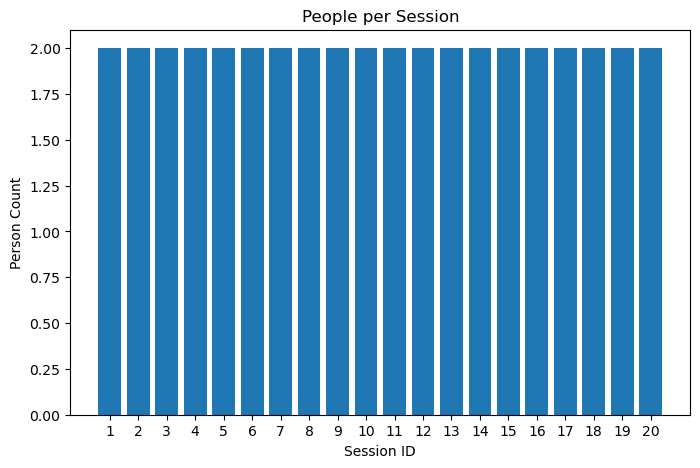

In [9]:
plt.figure(figsize=(8,5))
plt.bar(df_1["session_id"], df_1["person_count"])
plt.title("People per Session")
plt.xlabel("Session ID")
plt.ylabel("Person Count")
plt.xticks(df_1["session_id"])
plt.show()

### Ensure to close connection once complete.

In [10]:
cursor.close()
connection.close()
print("MySQL connection is closed")

MySQL connection is closed
